# Worksheet 5

## - 23MS121 
## - Manish Behera

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### ODEs Schema
$\large \text{Euler:} 
\qquad\qquad\quad\begin{aligned}[t]
y_{n+1} &= y_n + f(x_n, y_n) h
\end{aligned}$

$\large \text{Midpoint:}
\qquad\quad\begin{aligned}[t]
k1 &= h f(x_n, y_n) \\
y_{n+1} &= y_{n} + h f(x_n + \frac{h}{2}, y_n + \frac{k1}{2})
\end{aligned}$

$\large \text{Runge-Kutta:}
\quad\begin{aligned}[t]
k1 &= h f(x_n, y_n) \\
k2 &= h f(x_n + h/2, y_n + k1/2) \\
k3 &= h f(x_n + h/2, y_n + k2/2) \\
k4 &= h f(x_n + h, y_n + k3) \\
y_{n+1} &= y_{n} + (k1 + 2k2 + 2k3 + k4)/6
\end{aligned}$

$\Large {\text{Verlet:} 
\qquad\qquad\qquad\;\;\begin{aligned}[t]
y_{n+1} = 2y_n - y_{n-1} + a_n h^2
\end{aligned}
}$

$\Large {\text{Velocity Verlet:} 
\quad\begin{aligned}[t]
y_{n+1} &= y_n + v_n h + a_n h^2/2 \\
v_{n+1} &= v_n + h (a_n + a_{n+1})/2
\end{aligned}
}$

$\Large {\text{Leapfrog:} 
\qquad\qquad\begin{aligned}[t]
v_{n+1/2} &= v_n + h a_n/2 \\
y_{n+1} &= y_n + h v_{n+1/2} \\
v_{n+1} &= v_{n+1/2} + h a_{n+1}/2
\end{aligned}
}$

In [2]:
def euler(f1, x, y, h):
    return y + h * f1(x, y)

def midpoint(f1, x, y, h):
    k1 = h * f1(x, y)
    return y + h * f1(x + h / 2, y + k1 / 2)

def rk4(f1, x, y, h):
    k1 = h * f1(x, y)
    k2 = h * f1(x + h / 2, y + k1 / 2)
    k3 = h * f1(x + h / 2, y + k2 / 2)
    k4 = h * f1(x + h, y + k3)
    return y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

def caller(my_method, fn, y_ini, N, xs, h):
    """
    Uses a general-purpose integrator.
    method is typically `euler`, `midpoint`, or `rk4`, but can be another function with signature: method(fn, x, y, h).

    Returns an array of solutions (ys).
    """
    y = y_ini
    ys = np.zeros((N, len(y_ini)), dtype=np.float64)
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = my_method(fn, x, y, h)
    return ys

def verlet(f1, x, yn, ynm1, h):
    return 2*yn - ynm1 + f1(x, yn)*(h**2)


def velocity_verlet(f1, x, yn, vn, h):
    ynp1 = yn + vn*h + 0.5*f1(x, yn)*(h**2)
    vnp1 = vn + 0.5*(f1(x, yn) + f1(x + h, ynp1))*h
    return ynp1, vnp1

def leapfrog(f1, x, yn, vn, h):
    vnph = vn + 0.5*f1(x, yn)*h
    ynp1 = yn + vnph*h
    vnp1 = vnph + 0.5*f1(x + h, ynp1)*h
    return ynp1, vnp1

def caller_y(method, fn, y0, v0, N, xs, h):
    """
    Uses a position-only integrator (like Verlet).
    method is typically `verlet`, but can be another function with signature: method(fn, x, yn, ynm1, h).

    Returns an array of positions (ys).
    """
    ys = np.zeros(N)
    
    ys[0] = y0
    
    # We assume x0 is xs[0], if not specified otherwise.
    x0 = xs[0]
    
    # Often this is given. If not, we can approximate it using the initial acceleration. here we assume fn(x0, y0) gives the acceleration at the initial point. use s = v0*h + 0.5*a*h^2 to get the first step.
    ys[1] = y0 + v0*h + 0.5*fn(x0, y0)*(h**2)

    # Loop starts from the third point
    for i in range(2, N):
        x = xs[i]
        ys[i] = method(fn, x, ys[i-1], ys[i-2], h)
    
    return ys


def caller_yv(method, fn, y0, v0, N, xs, h):
    """
    Uses a position-velocity integrator (like Velocity Verlet or Leapfrog).
    method is typically `velocity_verlet` or `leapfrog`, 
    but can be another function with signature: method(fn, x, y, v, h).
    
    Returns arrays of positions (ys) and velocities (vs).
    """
    ys = np.zeros(N)
    vs = np.zeros(N)
    
    ys[0] = y0
    vs[0] = v0

    # loop range(1, N).
    for i in range(1, N):
        x = xs[i]
        ys[i], vs[i] = method(fn, x, ys[i-1], vs[i-1], h)
    
    return ys, vs



### Q1. 
(10 points) Two coupled first-order equations
dy
dt = p
dp
dt = −4π2y
define simple harmonic motion with period 1.
(a) (6 points) Use Verlet, velocity Verlet, and RK4 methods to solve the equations using h = 0.01
from tini = 0 to tfinal = 15. The given initial condition is y(0) = 1.0 and p(0) = 0.0. Plot the
solutions along with the exact solution.
(b) (2 points) Now choose h = 10.0n for n = −4 to n = −2 in steps of 0.2. For each h, keep
tfinal fixed and solve the above equations using the two methods. For each h, for each method,
estimate the error of the position value of the final point (absolute deviation from the exact
solution).
(c) (2 points) Plot and fit log10 h versus log10 of the error with a straight line to estimate the errors
of each of the method.

$ {\ddot{y} = -4 {\pi}^{2} y \\ 
\Rightarrow 
\begin{aligned}[t]
\dot{y} &= p \\
\dot{p} &= -4 {\pi}^{2} y
\end{aligned}\\
\Rightarrow
\dfrac{d}{dt}\begin{pmatrix}y[0] \\ y[1]\end{pmatrix} = \begin{pmatrix}0 & 1\\ -4 {\pi}^{2} & 0 \end{pmatrix}\begin{pmatrix}y[0] \\ y[1]\end{pmatrix} = \begin{pmatrix}y[1] \\ -4 {\pi}^{2} y[0]\end{pmatrix} 
}$

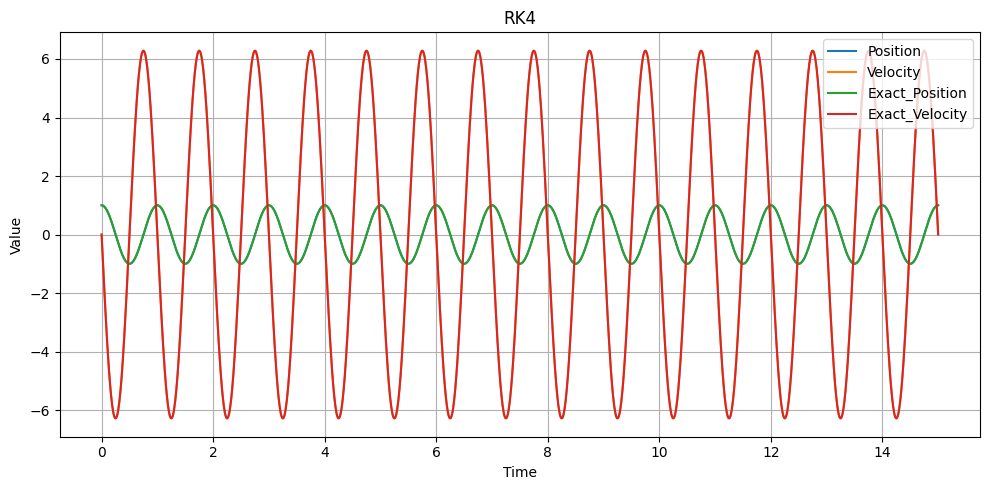

In [3]:
# Define the function g(t, y)
def g_ty(t, y):
    return np.asarray([y[1], -4*np.pi*np.pi*y[0]])
# Parameters
h = 1.0e-2
t0 = 0.0

N = 1501
ts = np.arange(t0, t0 + N * h, h)  # Generate range of x values

y_ini = np.asarray([1.0, 0.0])  # Initial condition


y_exact = np.cos(2*np.pi*ts)
p_exact = -2*np.pi*np.sin(2*np.pi*ts)

# Call the method
ysrk4 = caller(rk4, g_ty, y_ini, N, ts, h)

# Plot for RK4 method
plt.figure(figsize=(10,5))
plt.plot(ts, ysrk4[:, 0], label="Position")
plt.plot(ts, ysrk4[:, 1], label="Velocity")
plt.plot(ts, y_exact, label="Exact_Position")
plt.plot(ts, p_exact, label="Exact_Velocity")
plt.title("RK4")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid()

# Adjust layout
plt.tight_layout()
plt.show()

In [4]:
# Define the function g(t, y)
def g(t, y):
    return -4*np.pi*np.pi*y

# Step size and initial x-value
h = 1.0e-2
t0 = 0.0

# Number of steps
N = 1501

# Generate the array of t-values
ts = np.arange(t0, t0 + N * h, h)  # Generate range of x values

# Initial conditions
y0 = 1.0
v0 = 0.0

# Compute y-values using position-only Verlet
ysV = caller_y(verlet, g, y0, v0, N, ts, h)

# Compute y and v values using Velocity Verlet
ysVV, vsVV = caller_yv(velocity_verlet, g, y0, v0, N, ts, h)

# Compute y and v values using Leapfrog
ysL, vsL = caller_yv(leapfrog, g, y0, v0, N, ts, h)



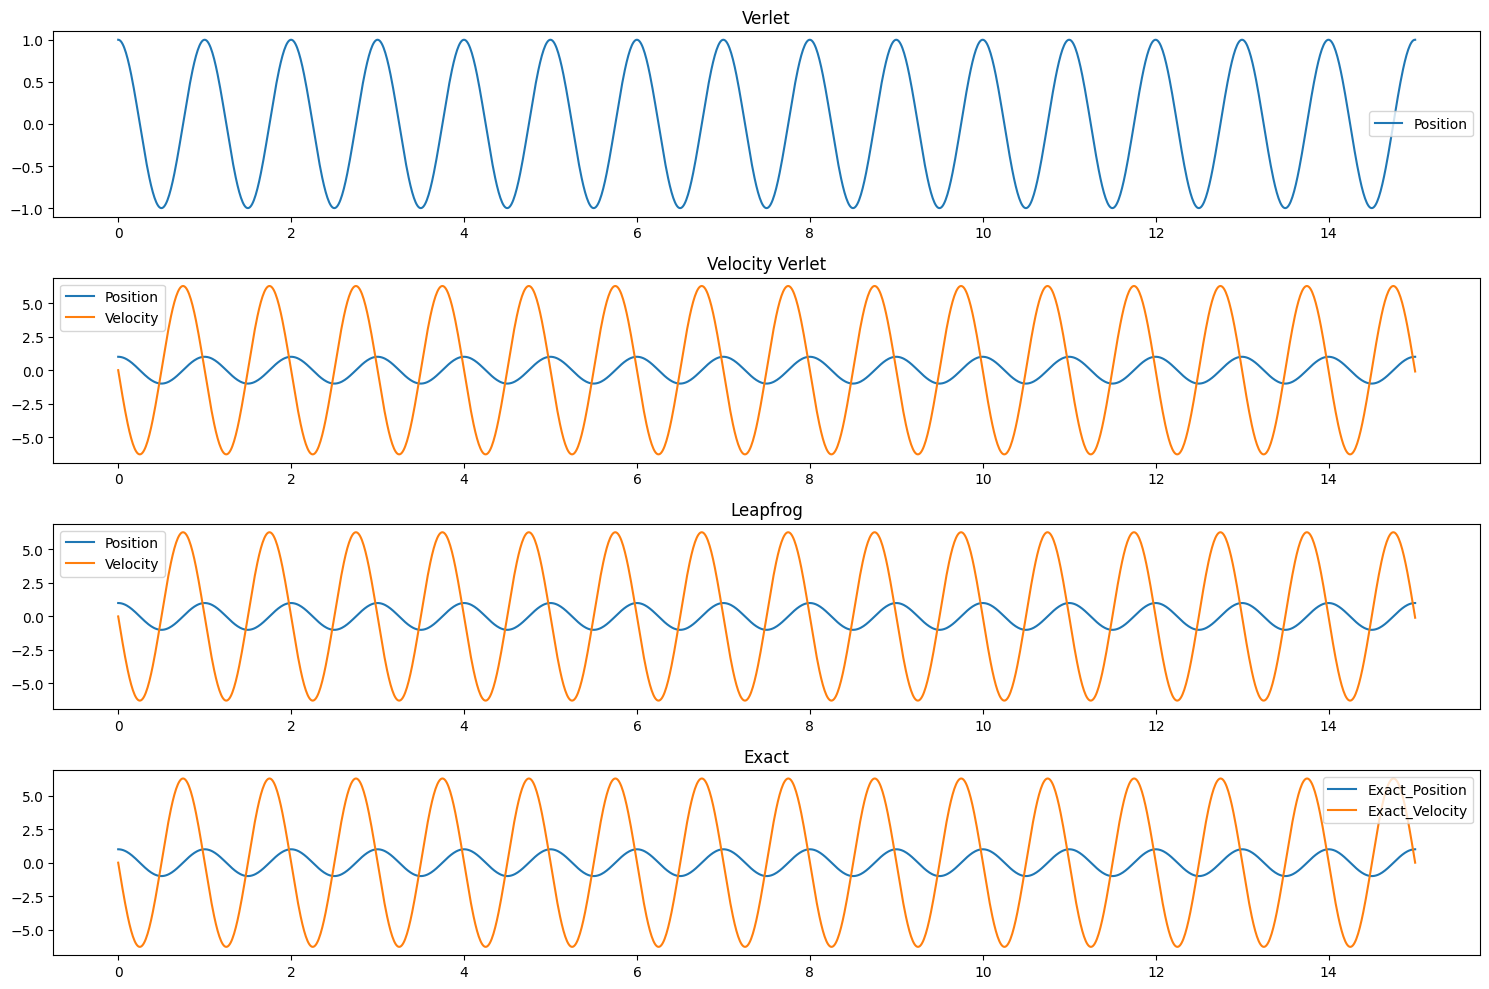

In [5]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 10))  # (width=9, height=4) in inches
# 1) Verlet
axes[0].plot(ts, ysV, label='Position')
axes[0].set_title('Verlet')
axes[0].legend()

# 2) Velocity Verlet
axes[1].plot(ts, ysVV, label='Position')
axes[1].plot(ts, vsVV, label='Velocity')
axes[1].set_title('Velocity Verlet')
axes[1].legend()

# 3) Leapfrog
axes[2].plot(ts, ysL, label='Position')
axes[2].plot(ts, vsL, label='Velocity')
axes[2].set_title('Leapfrog')
axes[2].legend()

#4) Exact
axes[3].plot(ts, y_exact, label="Exact_Position")
axes[3].plot(ts, p_exact, label="Exact_Velocity")
axes[3].set_title('Exact')
axes[3].legend()

plt.tight_layout()
plt.show()


In [6]:
# (b) Error analysis for RK4, Verlet, Velocity Verlet, and Leapfrog methods
hs = 10.0 ** np.arange(-4, -2.01, 0.2)

errors_rk4 = []
errors_verlet = []
errors_vel_verlet = []
errors_leapfrog = []

t0 = 0.0
tfinal = 15.0
y0 = 1.0
v0 = 0.0

def g_ty(t, y):
    return np.asarray([y[1], -4*np.pi*np.pi*y[0]])

def g(t, y):
    return -4*np.pi*np.pi*y

for h in hs:
    N = int((tfinal - t0) / h) + 1
    ts = np.linspace(t0, tfinal, N)
    y_ini = np.asarray([y0, v0])
    y_exact = np.cos(2*np.pi*ts[-1])
    # RK4
    ysrk4 = caller(rk4, g_ty, y_ini, N, ts, h)
    err_rk4 = abs(ysrk4[-1, 0] - y_exact)
    errors_rk4.append(err_rk4)
    # Verlet
    ysV = caller_y(verlet, g, y0, v0, N, ts, h)
    err_verlet = abs(ysV[-1] - y_exact)
    errors_verlet.append(err_verlet)
    # Velocity Verlet
    ysVV, vsVV = caller_yv(velocity_verlet, g, y0, v0, N, ts, h)
    err_vel_verlet = abs(ysVV[-1] - y_exact)
    errors_vel_verlet.append(err_vel_verlet)
    # Leapfrog
    ysL, vsL = caller_yv(leapfrog, g, y0, v0, N, ts, h)
    err_leapfrog = abs(ysL[-1] - y_exact)
    errors_leapfrog.append(err_leapfrog)

# Convert to numpy arrays
errors_rk4 = np.array(errors_rk4)
errors_verlet = np.array(errors_verlet)
errors_vel_verlet = np.array(errors_vel_verlet)
errors_leapfrog = np.array(errors_leapfrog)

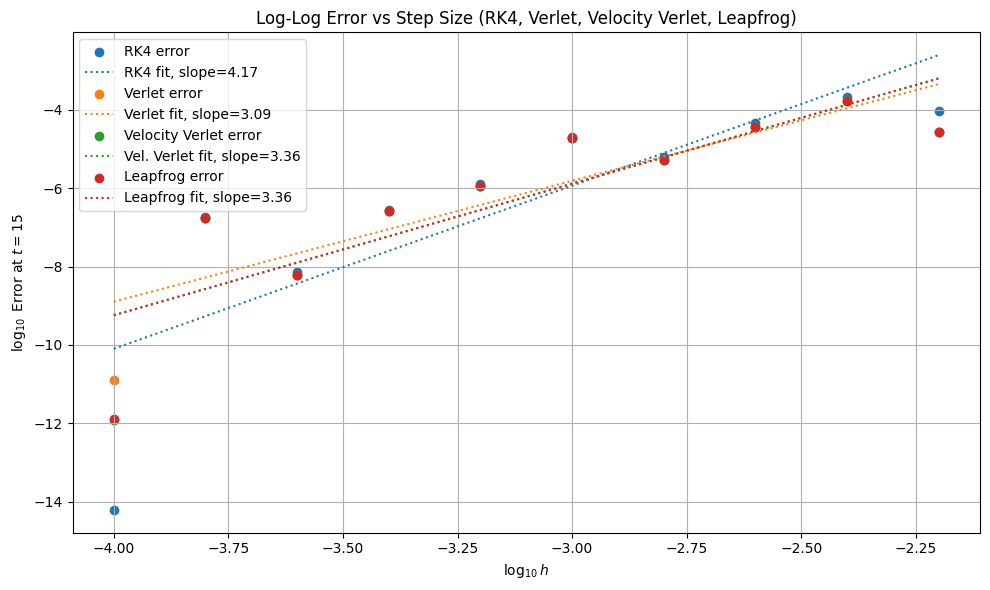

In [7]:
# (c) Log-Log plot and linear fit for error vs step size
from scipy.optimize import curve_fit

def linear(x, a, b):
    return a * x + b

log_hs = np.log10(hs)
log_err_rk4 = np.log10(errors_rk4)
log_err_verlet = np.log10(errors_verlet)
log_err_vel_verlet = np.log10(errors_vel_verlet)
log_err_leapfrog = np.log10(errors_leapfrog)

# Fit lines
params_rk4, _ = curve_fit(linear, log_hs, log_err_rk4)
params_verlet, _ = curve_fit(linear, log_hs, log_err_verlet)
params_vel_verlet, _ = curve_fit(linear, log_hs, log_err_vel_verlet)
params_leapfrog, _ = curve_fit(linear, log_hs, log_err_leapfrog)

xfit = np.linspace(log_hs[0], log_hs[-1], 200)
yfit_rk4 = linear(xfit, *params_rk4)
yfit_verlet = linear(xfit, *params_verlet)
yfit_vel_verlet = linear(xfit, *params_vel_verlet)
yfit_leapfrog = linear(xfit, *params_leapfrog)

plt.figure(figsize=(10, 6))
plt.scatter(log_hs, log_err_rk4, label="RK4 error", color="tab:blue")
plt.plot(xfit, yfit_rk4, color="tab:blue", linestyle=":", label=f"RK4 fit, slope={params_rk4[0]:.2f}")
plt.scatter(log_hs, log_err_verlet, label="Verlet error", color="tab:orange")
plt.plot(xfit, yfit_verlet, color="tab:orange", linestyle=":", label=f"Verlet fit, slope={params_verlet[0]:.2f}")
plt.scatter(log_hs, log_err_vel_verlet, label="Velocity Verlet error", color="tab:green")
plt.plot(xfit, yfit_vel_verlet, color="tab:green", linestyle=":", label=f"Vel. Verlet fit, slope={params_vel_verlet[0]:.2f}")
plt.scatter(log_hs, log_err_leapfrog, label="Leapfrog error", color="tab:red")
plt.plot(xfit, yfit_leapfrog, color="tab:red", linestyle=":", label=f"Leapfrog fit, slope={params_leapfrog[0]:.2f}")
plt.xlabel(r"$\log_{10} h$")
plt.ylabel(r"$\log_{10}$ Error at $t=15$")
plt.title("Log-Log Error vs Step Size (RK4, Verlet, Velocity Verlet, Leapfrog)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Q2:

#### (a) Equations of Motion


$$m \frac{dv_x}{dt} = -\gamma v_x \quad \Rightarrow \quad \frac{dv_x}{dt} = -\frac{\gamma}{m} v_x$$

$$m \frac{dv_y}{dt} = -mg - \gamma v_y \quad \Rightarrow \quad \frac{dv_y}{dt} = -g - \frac{\gamma}{m} v_y$$

**First-order system:**
$$\frac{dx}{dt} = v_x, \quad \frac{dy}{dt} = v_y$$
$$\frac{dv_x}{dt} = -\frac{\gamma}{m} v_x, \quad \frac{dv_y}{dt} = -g - \frac{\gamma}{m} v_y$$

**X-direction:** 
$$\dfrac{d}{dt}\begin{pmatrix}X[0] \\ X[1]\end{pmatrix} = \begin{pmatrix}0 & 1\\ 0 & -\frac{\gamma}{m} \end{pmatrix}\begin{pmatrix}X[0] \\ X[1]\end{pmatrix} = \begin{pmatrix}X[1] \\ -\frac{\gamma}{m} X[1]\end{pmatrix}$$

**Y-direction:** 
$$\dfrac{d}{dt}\begin{pmatrix}Y[0] \\ Y[1]\end{pmatrix} = \begin{pmatrix}0 & 1\\ 0 & -\frac{\gamma}{m} \end{pmatrix}\begin{pmatrix}Y[0] \\ Y[1]\end{pmatrix} + \begin{pmatrix}0 \\ -g\end{pmatrix} = \begin{pmatrix}Y[1] \\ -g - \frac{\gamma}{m} Y[1]\end{pmatrix}$$

#### (b) Trajectory calculation using Euler, Velocity Verlet, and RK4

We solve the equations of motion from the starting point until the projectile hits the ground ($y \leq 0$).

In [8]:
# Q2 (b) - Projectile motion with drag using Euler, Velocity Verlet, RK4

# Parameters
m = 2.0       # kg
g = 9.8       # m/s^2
gamma = 2.0   # kg/s
v0 = 10.0     # m/s
theta = np.radians(60)  # angle in radians

# Initial conditions
x0 = 0.0
y0 = 0.0
vx0 = v0 * np.cos(theta)
vy0 = v0 * np.sin(theta)


In [9]:
# Define the ODE functions for X and Y components
def f_x(t, X):
    return np.asarray([X[1], -(gamma/m) * X[1]])

def f_y(t, Y):
    return np.asarray([Y[1], -g - (gamma/m) * Y[1]])

# Function to find time of flight (when y returns to 0)
def find_time_of_flight(f_y, Y_ini, h=0.001, t_max=20.0):
    """
    Integrate y-component using RK4 until y becomes negative.
    Returns approximate time of flight.
    """
    Y = Y_ini.copy()
    t = 0.0
    while t < t_max:
        Y_new = rk4(f_y, t, Y, h)
        t += h
        # Check if y crossed zero (projectile hit ground)
        if Y_new[0] <= 0 and Y[0] > 0:
            # Linear interpolation to find exact crossing time
            t_flight = t - h + h * Y[0] / (Y[0] - Y_new[0])
            return t_flight
        Y = Y_new
    return t_max  # fallback

# Initial conditions for Y component: [y0, vy0]
Y_ini = np.asarray([y0, vy0])
X_ini = np.asarray([x0, vx0])

# Find time of flight
t_flight = find_time_of_flight(f_y, Y_ini, h=0.001)
print(f"Time of flight: {t_flight:.4f} s")

Time of flight: 1.4353 s


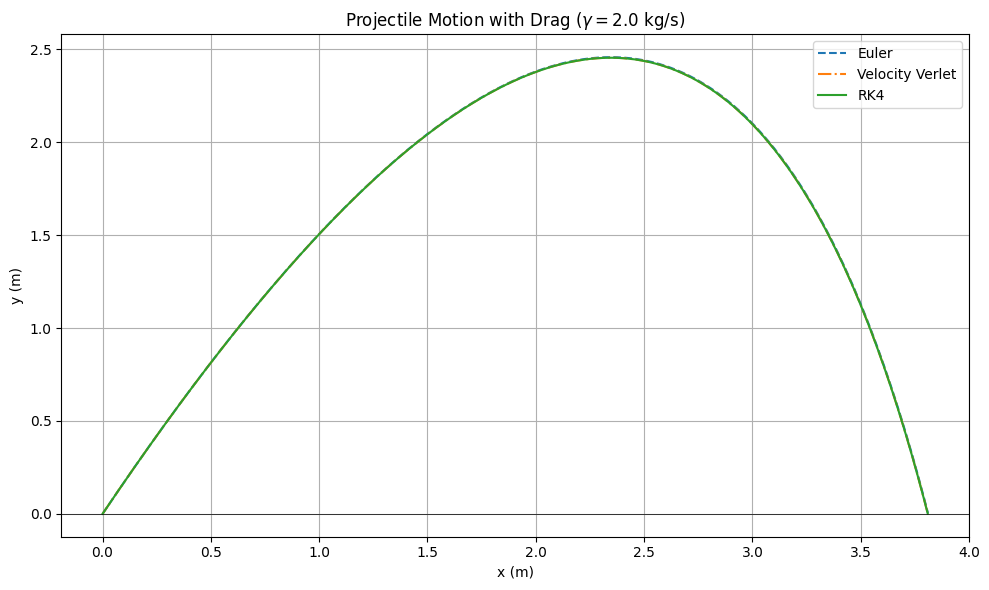

In [10]:
# (b) Solve trajectory using Euler, RK4, and Velocity Verlet

h = 0.001
N = int(t_flight / h) + 10  # Add buffer
ts = np.arange(0, N * h, h)

# RK4 for both X and Y components
X_rk4 = caller(rk4, f_x, X_ini, N, ts, h)
Y_rk4 = caller(rk4, f_y, Y_ini, N, ts, h)

# Euler for both X and Y components
X_euler = caller(euler, f_x, X_ini, N, ts, h)
Y_euler = caller(euler, f_y, Y_ini, N, ts, h)

# Velocity Verlet for projectile with drag (custom implementation)
# For drag force, acceleration depends on velocity: a = -gamma/m * v (for x), a = -g - gamma/m * v (for y)
def velocity_verlet_projectile(x0, y0, vx0, vy0, N, h, gamma_val):
    """Velocity Verlet for projectile with velocity-dependent drag."""
    xs = np.zeros(N)
    ys = np.zeros(N)
    vxs = np.zeros(N)
    vys = np.zeros(N)
    
    xs[0], ys[0] = x0, y0
    vxs[0], vys[0] = vx0, vy0
    
    for i in range(1, N):
        # Current accelerations
        ax = -(gamma_val/m) * vxs[i-1]
        ay = -g - (gamma_val/m) * vys[i-1]
        
        # Update positions
        xs[i] = xs[i-1] + vxs[i-1]*h + 0.5*ax*h**2
        ys[i] = ys[i-1] + vys[i-1]*h + 0.5*ay*h**2
        
        # Predict new velocities for acceleration calculation
        vx_pred = vxs[i-1] + ax*h
        vy_pred = vys[i-1] + ay*h
        
        # New accelerations
        ax_new = -(gamma_val/m) * vx_pred
        ay_new = -g - (gamma_val/m) * vy_pred
        
        # Update velocities
        vxs[i] = vxs[i-1] + 0.5*(ax + ax_new)*h
        vys[i] = vys[i-1] + 0.5*(ay + ay_new)*h
    
    return xs, ys, vxs, vys

# Velocity Verlet
xs_vv, ys_vv, vxs_vv, vys_vv = velocity_verlet_projectile(x0, y0, vx0, vy0, N, h, gamma)

# Trim to where y >= 0
mask_rk4 = Y_rk4[:, 0] >= 0
mask_euler = Y_euler[:, 0] >= 0
mask_vv = ys_vv >= 0

# Plot trajectories
plt.figure(figsize=(10, 6))
plt.plot(X_euler[mask_euler, 0], Y_euler[mask_euler, 0], label="Euler", linestyle="--")
plt.plot(xs_vv[mask_vv], ys_vv[mask_vv], label="Velocity Verlet", linestyle="-.")
plt.plot(X_rk4[mask_rk4, 0], Y_rk4[mask_rk4, 0], label="RK4", linestyle="-")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title(f"Projectile Motion with Drag ($\\gamma = {gamma}$ kg/s)")
plt.legend()
plt.grid()
plt.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

#### (c) Trajectories for varying drag coefficient $\gamma$

We vary $\gamma$ from 0 to 10 kg/s in steps of 1 and plot all trajectories on a single graph.

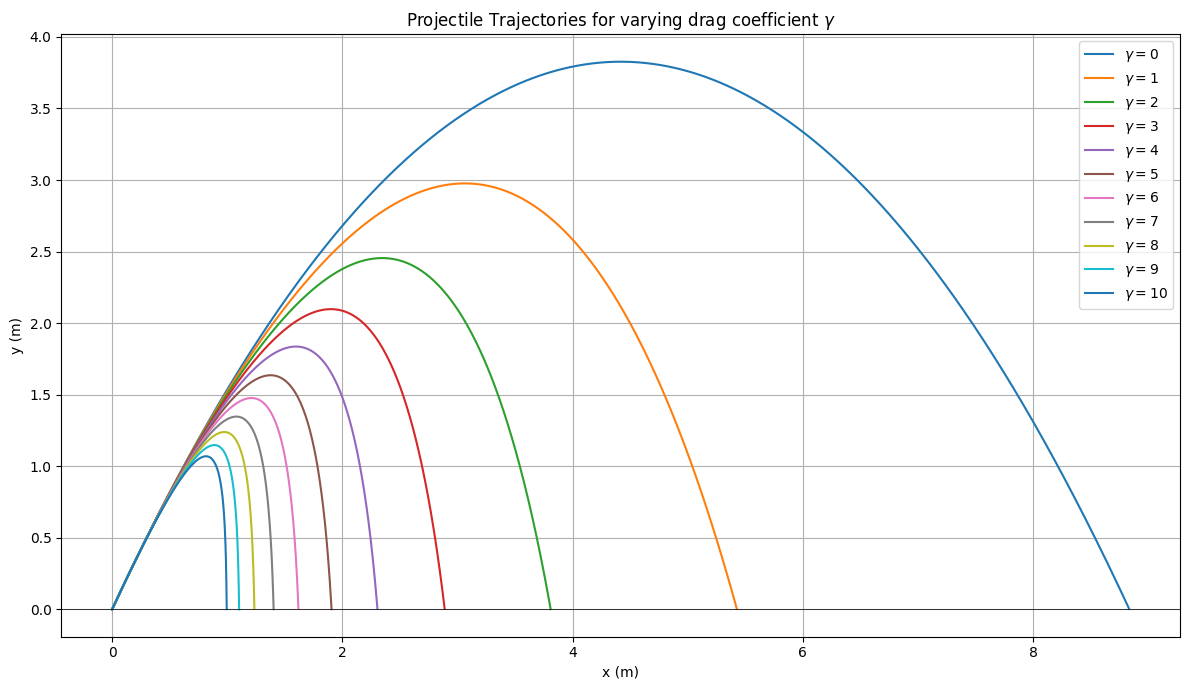

In [11]:
# (c) Varying gamma from 0 to 10 kg/s

gamma_values = np.arange(0, 11, 1)  # 0 to 10 in steps of 1
h = 0.001

plt.figure(figsize=(12, 7))

for gamma_val in gamma_values:
    # Redefine f_y with current gamma
    def f_y_gamma(t, Y, gam=gamma_val):
        return np.asarray([Y[1], -g - (gam/m) * Y[1]])
    
    def f_x_gamma(t, X, gam=gamma_val):
        return np.asarray([X[1], -(gam/m) * X[1]])
    
    # Find time of flight for this gamma
    t_flight_g = find_time_of_flight(f_y_gamma, Y_ini, h=0.001)
    N_g = int(t_flight_g / h) + 10
    ts_g = np.arange(0, N_g * h, h)
    
    # Solve using RK4
    X_g = caller(rk4, f_x_gamma, X_ini, N_g, ts_g, h)
    Y_g = caller(rk4, f_y_gamma, Y_ini, N_g, ts_g, h)
    
    # Trim to where y >= 0
    mask_g = Y_g[:, 0] >= 0
    plt.plot(X_g[mask_g, 0], Y_g[mask_g, 0], label=f"$\\gamma = {gamma_val}$")

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Projectile Trajectories for varying drag coefficient $\\gamma$")
plt.legend(loc='upper right')
plt.grid()
plt.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()